# Задание 2.2 - Введение в PyTorch

Для этого задания потребуется установить версию PyTorch 1.0

https://pytorch.org/get-started/locally/

В этом задании мы познакомимся с основными компонентами PyTorch и натренируем несколько небольших моделей.<br>
GPU нам пока не понадобится.

Основные ссылки:  
https://pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html  
https://pytorch.org/docs/stable/nn.html  
https://pytorch.org/docs/stable/torchvision/index.html  

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as dset
from torch.utils.data.sampler import SubsetRandomSampler, Sampler

from torchvision import transforms

import matplotlib.pyplot as plt
%matplotlib inline

from collections import Counter

import numpy as np

## Как всегда, начинаем с загрузки данных

PyTorch поддерживает загрузку SVHN из коробки.

In [2]:
transform = transforms.Compose([
                           transforms.ToTensor(),
                           transforms.Normalize(mean=[0.43,0.44,0.47],
                                               std=[0.20,0.20,0.20])                           
                       ])
# First, lets load the dataset
data_train = dset.SVHN('./data/', split='train',
                       transform=transform
                      )
data_test = dset.SVHN('./data/', split='test', 
                      transform=transform)

Хочу посмотреть на датасет

In [3]:
vars(data_train)

{'root': './data/',
 'transform': Compose(
     ToTensor()
     Normalize(mean=[0.43, 0.44, 0.47], std=[0.2, 0.2, 0.2])
 ),
 'target_transform': None,
 'transforms': StandardTransform
 Transform: Compose(
                ToTensor()
                Normalize(mean=[0.43, 0.44, 0.47], std=[0.2, 0.2, 0.2])
            ),
 'split': 'train',
 'url': 'http://ufldl.stanford.edu/housenumbers/train_32x32.mat',
 'filename': 'train_32x32.mat',
 'file_md5': 'e26dedcc434d2e4c54c9b2d4a06d8373',
 'data': array([[[[ 33,  15,  15, ...,  72,  82,  89],
          [ 28,  14,  14, ...,  40,  67,  83],
          [ 40,  18,  16, ...,  23,  35,  72],
          ...,
          [ 86,  87,  82, ..., 104, 104, 103],
          [ 84,  86,  82, ..., 110, 106, 106],
          [ 85,  89,  85, ..., 111, 109, 103]],
 
         [[ 30,  23,  17, ...,  65,  77,  79],
          [ 39,  25,  20, ...,  39,  58,  78],
          [ 41,  21,  17, ...,  29,  42,  69],
          ...,
          [ 81,  82,  79, ..., 104, 105, 105],
    

label = 2


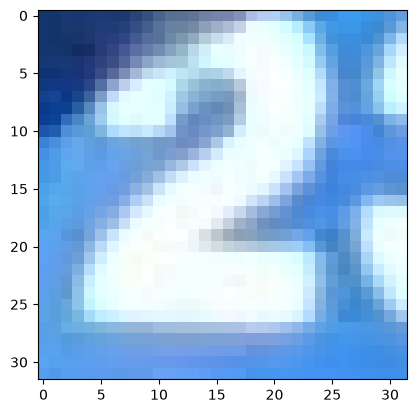

In [4]:
img = data_train.data[2]
label = data_train.labels[2]
plt.imshow(img.transpose(1, 2, 0))
print(f'label = {label}')

Теперь мы разделим данные на training и validation с использованием классов `SubsetRandomSampler` и `DataLoader`.

`DataLoader` подгружает данные, предоставляемые классом `Dataset`, во время тренировки и группирует их в батчи.
Он дает возможность указать `Sampler`, который выбирает, какие примеры из датасета использовать для тренировки. Мы используем это, чтобы разделить данные на training и validation.

Подробнее: https://pytorch.org/tutorials/beginner/data_loading_tutorial.html

In [5]:
batch_size = 64

data_size = data_train.data.shape[0]
validation_split = 0.2
split = int(np.floor(validation_split * data_size))
indices = list(range(data_size))
np.random.shuffle(indices)

train_indices, val_indices = indices[split:], indices[:split]

train_sampler = SubsetRandomSampler(train_indices)
val_sampler = SubsetRandomSampler(val_indices)

train_loader = torch.utils.data.DataLoader(data_train, batch_size=batch_size, 
                                           sampler=train_sampler)
val_loader = torch.utils.data.DataLoader(data_train, batch_size=batch_size,
                                         sampler=val_sampler)

В нашей задаче мы получаем на вход изображения, но работаем с ними как с одномерными массивами. Чтобы превратить многомерный массив в одномерный, мы воспользуемся очень простым вспомогательным модулем `Flattener`.

In [6]:
sample, label = data_train[0]
print("SVHN data sample shape: ", sample.shape)
print(f"SVHN label type: {type(label)}")
# As you can see, the data is shaped like an image

# We'll use a special helper module to shape it into a tensor
class Flattener(nn.Module):
    def forward(self, x):
        batch_size, *_ = x.shape
        return torch.flatten(x, start_dim=1)

SVHN data sample shape:  torch.Size([3, 32, 32])
SVHN label type: <class 'int'>


И наконец, мы создаем основные объекты PyTorch:
- `nn_model` - собственно, модель с нейросетью
- `loss` - функцию ошибки, в нашем случае `CrossEntropyLoss`
- `optimizer` - алгоритм оптимизации, в нашем случае просто `SGD`

In [7]:
nn_model = nn.Sequential(
            Flattener(),
            nn.Linear(3*32*32, 100),
            nn.ReLU(),
            nn.Linear(100, 10), 
         )
nn_model.to(dtype=torch.float32)

# We will minimize cross-entropy between the ground truth and
# network predictions using an SGD optimizer
loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(nn_model.parameters(), lr=1e-2, weight_decay=1e-1)

## Тренируем!

Ниже приведена функция `train_model`, реализующая основной цикл тренировки PyTorch.

Каждую эпоху эта функция вызывает функцию `compute_accuracy`, которая вычисляет точность на validation, эту последнюю функцию предлагается реализовать вам.

In [21]:
# This is how to implement the same main train loop in PyTorch. Pretty easy, right?

def train_model(model, train_loader, val_loader, loss, optimizer, num_epochs, lr_sched=None):    
    loss_history = []
    train_history = []
    val_history = []

    for epoch in range(num_epochs):
        model.train() # Enter train mode
        
        loss_accum = 0
        correct_samples = 0
        total_samples = 0
        for i_step, (x, y) in enumerate(train_loader):
            prediction = model(x)    
            loss_value = loss(prediction, y)
            optimizer.zero_grad()
            loss_value.backward()
            optimizer.step()
            
            
            _, indices = torch.max(prediction, dim=1)
            correct_samples += torch.sum(indices == y)
            total_samples += y.shape[0]
            
            loss_accum += loss_value

            
        ave_loss = loss_accum / (i_step + 1)
        train_accuracy = float(correct_samples) / total_samples
        val_accuracy, val_loss = compute_accuracy(model, loss, val_loader)
        
        loss_history.append(float(ave_loss))
        train_history.append(train_accuracy)
        val_history.append(val_accuracy)

        if lr_sched is not None:
            lr_sched.step(val_loss)
        
        print("Epoch: [%i / %i]. Average loss: %f, Train accuracy: %f, Val accuracy: %f" % (epoch+1, num_epochs, ave_loss, train_accuracy, val_accuracy))
        
    return loss_history, train_history, val_history
        
def compute_accuracy(model, loss_model, loader):
    """
    Computes accuracy on the dataset wrapped in a loader
    
    Returns: accuracy as a float value between 0 and 1
    """
    model.eval() # Evaluation mode
    # TODO: Implement the inference of the model on all of the batches from loader,
    #       and compute the overall accuracy.
    # Hint: PyTorch has the argmax function!
    total_correct = 0.0
    total_targets = 0.0
    total_loss = 0.0
    with torch.no_grad():
        for i, (x, target) in enumerate(loader):
            pred = model(x)
            loss = loss_model(pred, target)
            total_loss += loss.item()
            total_correct += (torch.argmax(pred, dim=1) == target).sum().item()    
            total_targets += target.shape[0]
            
    return total_correct / total_targets, total_loss / (i + 1)

loss_history, train_history, val_history = train_model(nn_model, train_loader, val_loader, loss, optimizer, 3)

Epoch: [1 / 3]. Average loss: 1.661475, Train accuracy: 0.547657, Val accuracy: 0.551771
Epoch: [2 / 3]. Average loss: 1.661987, Train accuracy: 0.546975, Val accuracy: 0.558801
Epoch: [3 / 3]. Average loss: 1.661203, Train accuracy: 0.546906, Val accuracy: 0.561054


## После основного цикла

Посмотрим на другие возможности и оптимизации, которые предоставляет PyTorch.

Добавьте еще один скрытый слой размера 100 нейронов к модели

In [9]:
# Since it's so easy to add layers, let's add some!

# TODO: Implement a model with 2 hidden layers of the size 100
nn_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(3*32*32, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 10)
)
nn_model.to(dtype=torch.float32)

optimizer = optim.SGD(nn_model.parameters(), lr=1e-2, weight_decay=1e-1)
loss_history, train_history, val_history = train_model(nn_model, train_loader, val_loader, loss, optimizer, 5)

Epoch: [1 / 5]. Average loss: 2.163925, Train accuracy: 0.206054, Val accuracy: 0.248993
Epoch: [2 / 5]. Average loss: 2.004498, Train accuracy: 0.281985, Val accuracy: 0.348645
Epoch: [3 / 5]. Average loss: 1.803010, Train accuracy: 0.383220, Val accuracy: 0.410074
Epoch: [4 / 5]. Average loss: 1.707687, Train accuracy: 0.419616, Val accuracy: 0.433349
Epoch: [5 / 5]. Average loss: 1.679106, Train accuracy: 0.433812, Val accuracy: 0.432530


Добавьте слой с Batch Normalization

In [10]:
# We heard batch normalization is powerful, let's use it!
# TODO: Add batch normalization after each of the hidden layers of the network, before or after non-linearity
# Hint: check out torch.nn.BatchNorm1d

nn_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(3*32*32, 100, bias=False),
    nn.BatchNorm1d(100),
    nn.ReLU(),
    nn.Linear(100, 100, bias=False),
    nn.BatchNorm1d(100),
    nn.ReLU(),
    nn.Linear(100, 10)
)

loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(nn_model.parameters(), lr=1e-3, weight_decay=1e-1)
loss_history, train_history, val_history = train_model(nn_model, train_loader, val_loader, loss, optimizer, 5)

Epoch: [1 / 5]. Average loss: 2.072739, Train accuracy: 0.315548, Val accuracy: 0.429390
Epoch: [2 / 5]. Average loss: 1.801705, Train accuracy: 0.463502, Val accuracy: 0.515801
Epoch: [3 / 5]. Average loss: 1.668685, Train accuracy: 0.534416, Val accuracy: 0.555252
Epoch: [4 / 5]. Average loss: 1.581866, Train accuracy: 0.575692, Val accuracy: 0.598935
Epoch: [5 / 5]. Average loss: 1.518244, Train accuracy: 0.598778, Val accuracy: 0.615453


Добавьте уменьшение скорости обучения по ходу тренировки.

In [11]:
# Learning rate annealing
# Reduce your learning rate 2x every 2 epochs
# Hint: look up learning rate schedulers in PyTorch. You might need to extend train_model function a little bit too!

nn_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(3*32*32, 100, bias=False),
    nn.BatchNorm1d(100),
    nn.ReLU(),
    nn.Linear(100, 100, bias=False),
    nn.BatchNorm1d(100),
    nn.ReLU(),
    nn.Linear(100, 10)
)

loss = nn.CrossEntropyLoss()
opt = torch.optim.SGD(nn_model.parameters(), lr=1e-3, weight_decay=1e-1)
lr_sched = torch.optim.lr_scheduler.StepLR(opt, 2, gamma=0.5)
loss_history, train_history, val_history = train_model(nn_model, train_loader, val_loader, loss, opt, 6, lr_sched)

Epoch: [1 / 6]. Average loss: 2.069220, Train accuracy: 0.298297, Val accuracy: 0.435738
Epoch: [2 / 6]. Average loss: 1.783919, Train accuracy: 0.480992, Val accuracy: 0.537779


KeyboardInterrupt: 

# Визуализируем ошибки модели

Попробуем посмотреть, на каких изображениях наша модель ошибается.
Для этого мы получим все предсказания модели на validation set и сравним их с истинными метками (ground truth).

Первая часть - реализовать код на PyTorch, который вычисляет все предсказания модели на validation set.  
Чтобы это сделать мы приводим код `SubsetSampler`, который просто проходит по всем заданным индексам последовательно и составляет из них батчи. 

Реализуйте функцию `evaluate_model`, которая прогоняет модель через все сэмплы validation set и запоминает предсказания модели и истинные метки.

In [ ]:
class SubsetSampler(Sampler):
    r"""Samples elements with given indices sequentially

    Arguments:
        indices (ndarray): indices of the samples to take
    """

    def __init__(self, indices):
        self.indices = indices

    def __iter__(self):
        return (self.indices[i] for i in range(len(self.indices)))

    def __len__(self):
        return len(self.indices)

In [ ]:
sampler = SubsetSampler([1,4,5])
for i in sampler:
    print(i)

1
4
5


In [ ]:
def evaluate_model(model, dataset, indices):
    """
    Computes predictions and ground truth labels for the indices of the dataset
    
    Returns: 
    predictions: np array of ints - model predictions
    grount_truth: np array of ints - actual labels of the dataset
    """
    model.eval() # Evaluation mode
    
    # TODO: Evaluate model on the list of indices and capture predictions
    # and ground truth labels
    # Hint: SubsetSampler above could be useful!
    data_loader = torch.utils.data.DataLoader(dataset, sampler=SubsetSampler(indices))
    predictions = []
    ground_truth = []
    with torch.no_grad():
        for x, target in data_loader:
            logits = model(x)
            pred = torch.argmax(logits, dim=1)
            predictions.extend(pred.tolist())
            ground_truth.extend(target.tolist())
    
    return np.asarray(predictions, dtype=np.int64), np.asarray(ground_truth, dtype=np.int64)

# Evaluate model on validation
predictions, gt = evaluate_model(nn_model, data_train, val_indices)
assert len(predictions) == len(val_indices)
assert len(gt) == len(val_indices)
assert gt[100] == data_train[val_indices[100]][1]
assert np.any(np.not_equal(gt, predictions))

## Confusion matrix
Первая часть визуализации - вывести confusion matrix (https://en.wikipedia.org/wiki/Confusion_matrix ).

Confusion matrix - это матрица, где каждой строке соответствуют классы предсказанный, а столбцу - классы истинных меток (ground truth). Число с координатами `i,j` - это количество сэмплов класса `j`, которые модель считает классом `i`.

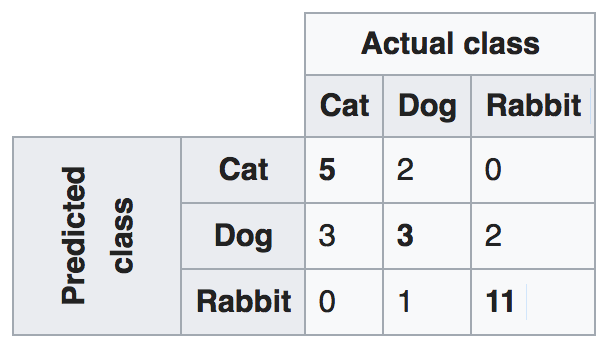

Для того, чтобы облегчить вам задачу, ниже реализована функция `visualize_confusion_matrix` которая визуализирует такую матрицу.  
Вам осталось реализовать функцию `build_confusion_matrix`, которая ее вычислит.

Результатом должна быть матрица 10x10.

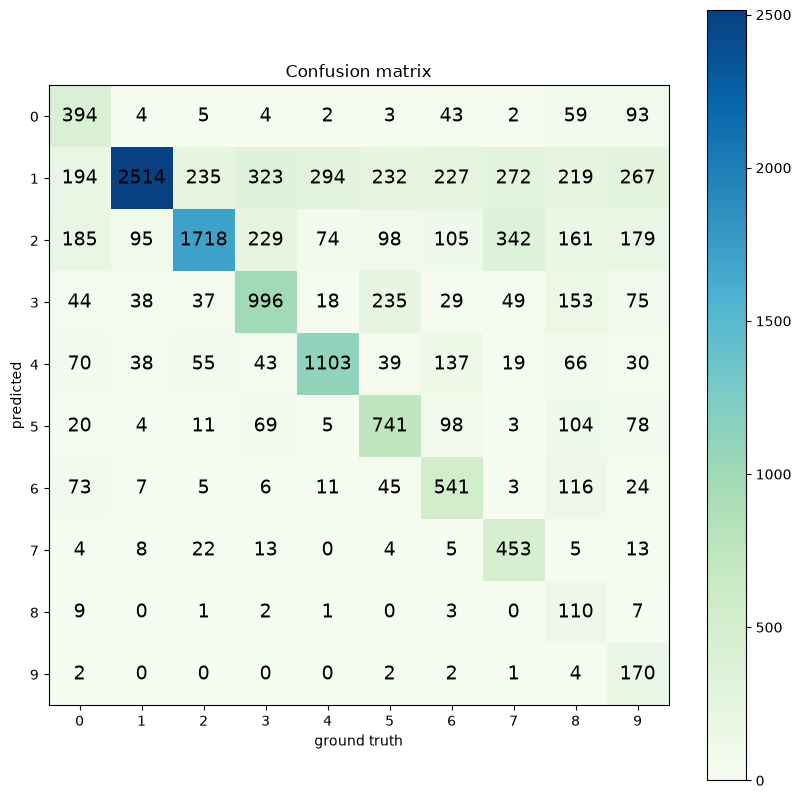

In [ ]:
def visualize_confusion_matrix(confusion_matrix):
    """
    Visualizes confusion matrix
    
    confusion_matrix: np array of ints, x axis - predicted class, y axis - actual class
                      [i][j] should have the count of samples that were predicted to be class i,
                      but have j in the ground truth
                     
    """
    # Adapted from 
    # https://stackoverflow.com/questions/2897826/confusion-matrix-with-number-of-classified-misclassified-instances-on-it-python
    assert confusion_matrix.shape[0] == confusion_matrix.shape[1]
    size = confusion_matrix.shape[0]
    fig = plt.figure(figsize=(10,10))
    plt.title("Confusion matrix")
    plt.ylabel("predicted")
    plt.xlabel("ground truth")
    res = plt.imshow(confusion_matrix, cmap='GnBu', interpolation='nearest')
    cb = fig.colorbar(res)
    plt.xticks(np.arange(size))
    plt.yticks(np.arange(size))
    for i, row in enumerate(confusion_matrix):
        for j, count in enumerate(row):
            plt.text(j, i, count, fontsize=14, horizontalalignment='center', verticalalignment='center')

def build_confusion_matrix(predictions, ground_truth):
    """
    Builds confusion matrix from predictions and ground truth

    predictions: np array of ints, model predictions for all validation samples
    ground_truth: np array of ints, ground truth for all validation samples
    
    Returns:
    np array of ints, (10,10), counts of samples for predicted/ground_truth classes
    """
    
    confusion_matrix = np.zeros((10,10), np.int64)
    
    # TODO: Implement filling the prediction matrix
    for p, gt in zip(predictions, ground_truth):
            confusion_matrix[p, gt] += 1
    

    return confusion_matrix

confusion_matrix = build_confusion_matrix(predictions, gt)
visualize_confusion_matrix(confusion_matrix)

Наконец, посмотрим на изображения, соответствующие некоторым элементам этой матрицы.

Как и раньше, вам дана функция `visualize_images`, которой нужно воспрользоваться при реализации функции `visualize_predicted_actual`. Эта функция должна вывести несколько примеров, соответствующих заданному элементу матрицы.

Визуализируйте наиболее частые ошибки и попробуйте понять, почему модель их совершает.

In [ ]:
test_p = np.array([1, 2, 3, 1])
p_c = 1
test_p_f = test_p[test_p == p_c]
test_p_f, test_p == p_c

(array([1, 1]), array([ True, False, False,  True]))

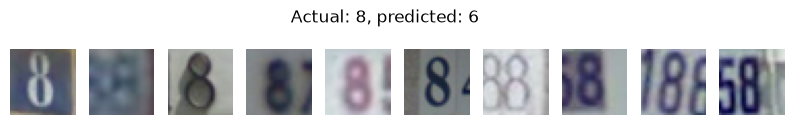

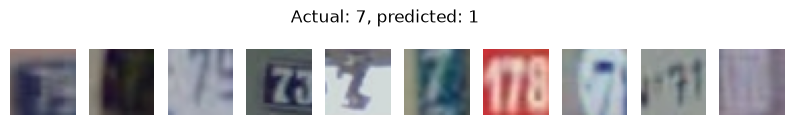

In [ ]:
data_train_images = dset.SVHN('./data/', split='train')

def visualize_images(indices, data, title='', max_num=10):
    """
    Visualizes several images from the dataset
 
    indices: array of indices to visualize
    data: torch Dataset with the images
    title: string, title of the plot
    max_num: int, max number of images to display
    """
    to_show = min(len(indices), max_num)
    fig = plt.figure(figsize=(10,1.5))
    fig.suptitle(title)
    for i, index in enumerate(indices[:to_show]):
        plt.subplot(1,to_show, i+1)
        plt.axis('off')
        sample = data[index][0]
        plt.imshow(sample)
        
def visualize_predicted_actual(predicted_class, gt_class, predictions, groud_truth, val_indices, data):
    """
    Visualizes images of a ground truth class which were predicted as the other class 
    
    predicted: int 0-9, index of the predicted class
    gt_class: int 0-9, index of the ground truth class
    predictions: np array of ints, model predictions for all validation samples
    ground_truth: np array of ints, ground truth for all validation samples
    val_indices: np array of ints, indices of validation samples
    """

    # TODO: Implement visualization using visualize_images above
    # predictions and ground_truth are provided for validation set only, defined by val_indices
    # Hint: numpy index arrays might be helpful
    # https://docs.scipy.org/doc/numpy/user/basics.indexing.html#index-arrays
    # Please make the title meaningful!
    mask = (predictions == predicted_class) & (groud_truth == gt_class)
    val_indices_filtered = val_indices[mask]
    visualize_images(val_indices_filtered, data, title=f"Actual: {gt_class}, predicted: {predicted_class}")

visualize_predicted_actual(6, 8, predictions, gt, np.array(val_indices), data_train_images)
visualize_predicted_actual(1, 7, predictions, gt, np.array(val_indices), data_train_images)

# Переходим к свободным упражнениям!

Натренируйте модель как можно лучше - экспериментируйте сами!
Что следует обязательно попробовать:
- перебор гиперпараметров с помощью валидационной выборки
- другие оптимизаторы вместо SGD
- изменение количества слоев и их размеров
- наличие Batch Normalization

Но ограничиваться этим не стоит!

Точность на тестовой выборке должна быть доведена до **80%**

In [ ]:
# Experiment here!
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(3*32*32, 1500, bias=False),
    nn.BatchNorm1d(1500),
    nn.ReLU(),
    nn.Linear(1500, 1000, bias=False),
    nn.BatchNorm1d(1000),
    nn.ReLU(),
    nn.Linear(1000, 800, bias=False),
    nn.BatchNorm1d(800),
    nn.ReLU(),
    nn.Linear(800, 200, bias=False),
    nn.BatchNorm1d(200),
    nn.ReLU(),
    nn.Linear(200, 10)
)

loss_model = nn.CrossEntropyLoss()
opt = torch.optim.SGD(model.parameters(), lr=0.1)
lr_sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5)


In [23]:
EPOCHES = 25
loss_history, train_history, val_history = train_model(model, train_loader, val_loader, loss_model, opt, EPOCHES, lr_sched)

Epoch: [1 / 25]. Average loss: 1.178162, Train accuracy: 0.611610, Val accuracy: 0.707051
Epoch: [2 / 25]. Average loss: 0.798464, Train accuracy: 0.744480, Val accuracy: 0.749573
Epoch: [3 / 25]. Average loss: 0.673601, Train accuracy: 0.787155, Val accuracy: 0.794553
Epoch: [4 / 25]. Average loss: 0.588080, Train accuracy: 0.814865, Val accuracy: 0.799604
Epoch: [5 / 25]. Average loss: 0.535255, Train accuracy: 0.829830, Val accuracy: 0.821446
Epoch: [6 / 25]. Average loss: 0.488387, Train accuracy: 0.843975, Val accuracy: 0.823766
Epoch: [7 / 25]. Average loss: 0.444082, Train accuracy: 0.857370, Val accuracy: 0.800764
Epoch: [8 / 25]. Average loss: 0.413471, Train accuracy: 0.869211, Val accuracy: 0.833663
Epoch: [9 / 25]. Average loss: 0.382333, Train accuracy: 0.876634, Val accuracy: 0.836189
Epoch: [10 / 25]. Average loss: 0.359517, Train accuracy: 0.884551, Val accuracy: 0.836325
Epoch: [11 / 25]. Average loss: 0.331378, Train accuracy: 0.892878, Val accuracy: 0.839601
Epoch: [

In [25]:
# Как всегда, в конце проверяем на test set
test_loader = torch.utils.data.DataLoader(data_test, batch_size=batch_size)
test_accuracy, test_loss = compute_accuracy(model, loss_model, test_loader)
print("Test accuracy: %2.4f" % test_accuracy)
print(f'Test loss: {test_loss}')

Test accuracy: 0.8464
Test loss: 0.663907044569456
